# Lab 1: Titanic Dataset Tutorial

In this lab, we will work with the famous Titanic dataset, a classic in data science and machine learning education. The goal of this lab is to predict passenger survival based on features such as age, fare, sex, and passenger class. You will start by exploring the dataset and understanding its structure, including the types of variables it contains. Then, we will clean the data to handle missing values and ensure it is ready for modeling. Next, you’ll engineer new features to help the model understand complex relationships more effectively. After that, we’ll visualize the data to draw insights from distributions and categorical comparisons. Finally, you’ll build a machine learning model to classify survival and interpret its results using evaluation metrics and visual tools like confusion matrices.


In this step, we begin by importing necessary Python libraries such as pandas, numpy, and matplotlib. These libraries are crucial for data handling, numerical operations, and visualization. We then load the Titanic dataset into a pandas DataFrame from a CSV file. This dataset contains details about the passengers, including age, gender, ticket fare, and whether they survived. It's important to check the first few rows to get a sense of what the dataset looks like. This helps us confirm the data has loaded correctly and familiarize ourselves with the features. We are preparing to inspect the dataset in more depth in the next step.

## 🔍 Step 1: Load and Explore the Dataset

We start by importing necessary libraries and loading the Titanic dataset into a DataFrame.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


This section focuses on understanding the structure of the dataset in more detail. We use the `.info()` method to see how many non-null values each column has, which tells us about missing data. The `.describe()` method provides statistical summaries for numerical columns. These summaries include mean, standard deviation, and quartile ranges. Such information is useful for detecting outliers or data entry errors. We also begin considering which columns may need to be cleaned or transformed. This foundational understanding will guide how we handle the data in subsequent steps.

## 📋 Step 2: Initial Data Inspection

Use `.info()` to understand datatypes and missing values, and `.describe()` to view statistical summaries.


In [2]:
df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Data cleaning is one of the most important tasks in any data analysis workflow. Here, we deal with missing values, remove unnecessary columns, and format the data into a more useful structure. Columns with too many missing entries may be dropped. Others might be filled in with average or most frequent values. We also convert data types if needed to ensure consistency in calculations. Cleaned data allows machine learning models to function properly and yield more accurate results. This sets the stage for constructing new features in the next step.

## 🧹 Step 3: Clean the Data

We drop rows with critical missing values and convert date columns if needed.


In [3]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Feature engineering involves creating new columns based on existing ones to capture more useful information. This step can significantly boost model performance. For example, we might combine the number of siblings and parents aboard into a single column representing family size. We can also derive new boolean columns like `is_alone`, which flag passengers traveling solo. These engineered features help the model detect patterns that aren’t obvious in raw data. They also allow us to customize our inputs based on domain knowledge. Thoughtful feature engineering can be the key to building strong predictive models.

## 🏗️ Step 4: Feature Engineering

We create new features like `family_size` and `is_alone` to enrich the data with behavioral context.


In [4]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Visualization is a powerful tool to uncover trends and relationships in the data. We use plots like bar charts, histograms, and count plots to explore distributions. For example, visualizing survival rates across different age groups or passenger classes can show us which factors influence survival. Such insights help guide feature selection and hypothesis generation. Visualization also helps communicate findings clearly. Patterns that may be difficult to detect in numbers alone become obvious in graphs. This step enhances both model design and interpretability.

## 📊 Step 5: Visualize Key Patterns

We visualize how variables like sex and age relate to survival using count plots and histograms.


In [5]:
# Fill missing age with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing embarked with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Fill missing embark_town with mode
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Safely fill missing values in categorical 'deck'
if pd.api.types.is_categorical_dtype(df['deck']):
    df['deck'] = df['deck'].cat.add_categories('Unknown')
df['deck'] = df['deck'].fillna('Unknown')


/tmp/ipykernel_31/1514271827.py:11: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df['deck']):


In [6]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In this step, we train a classifier to predict survival outcomes. We use a Random Forest Classifier, which is a robust ensemble method. It works by building multiple decision trees and averaging their results. Before training, we divide the dataset into training and testing subsets. This helps us evaluate the model's ability to generalize to new data. We then fit the model on the training data. Once trained, the model can make predictions on unseen data, which we evaluate next.

##  Step 6: Train a Machine Learning Model

We build a Random Forest model using scikit-learn to predict survival based on engineered features.


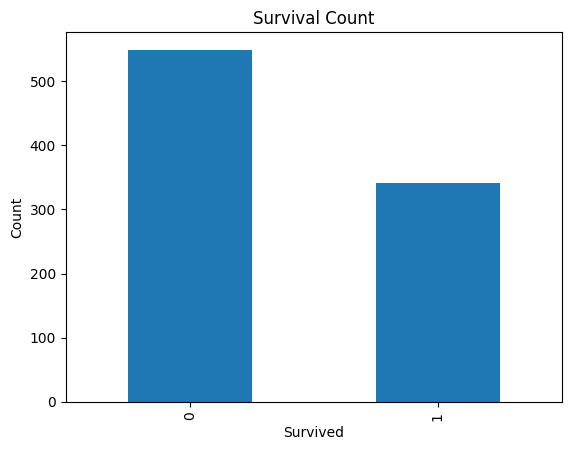

In [7]:
df['survived'].value_counts().plot(kind='bar', title='Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()


Model evaluation tells us how well our classifier is performing. One common metric is accuracy, which measures the percentage of correct predictions. But accuracy alone can be misleading, especially in imbalanced datasets. That's where confusion matrices come in—they show true positives, true negatives, false positives, and false negatives. This gives a more nuanced view of model performance. We visualize the confusion matrix to better understand these components. This helps us identify strengths and weaknesses in our model.

## Step 7: Evaluate the Model

We measure the performance of the model using accuracy score and visualize confusion matrix.


In [8]:
df.corr(numeric_only=True)


,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.247704,0.171647
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.247704,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.171647,-0.584471,-0.583398,-0.271832,0.404744,1.000000


### Plotting the Confusion Matrix

To better understand how our model performs, we visualize a confusion matrix using seaborn heatmap. This matrix shows the counts of true positives, true negatives, false positives, and false negatives.


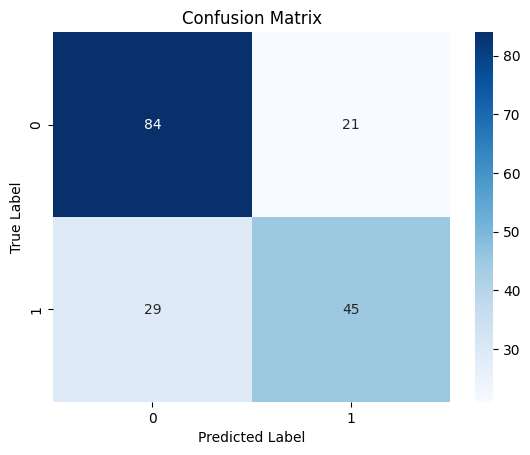

In [9]:
# Recreate the train/test split and model for self-contained confusion matrix generation

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Features and target
features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
X = df[features]
y = df['survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Generate predictions
y_pred_class = model.predict(X_test)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


## Self-Assessment Quiz

Test your understanding of the concepts covered in this lab. Try to answer the questions before scrolling to the answers at the end of this notebook.


### Quiz Questions

**1. What is the target variable in this dataset?**  
a) fare  
b) age  
c) survived  
d) sex  

**2. Which features are categorical vs numerical?**  
a) sex and embarked are categorical; age and fare are numerical  
b) All features are categorical  
c) All features are numerical  
d) Only survived is numerical  

**3. Why might `fare` and `pclass` influence survival?**  
a) They don’t affect survival  
b) They indicate wealth/class which influenced access to lifeboats  
c) They are randomly distributed  
d) None of the above  

**4. What does a confusion matrix tell us?**  
a) It shows data types  
b) It shows training time  
c) It shows true vs predicted classifications  
d) It shows feature correlations  

**5. How can we improve this model further?**  
a) Remove more rows  
b) Reduce features  
c) Add feature engineering and try hyperparameter tuning  
d) Use fewer samples  


## Quiz Answers and Explanations

**1. What is the target variable in this dataset?**  
**Answer: c) survived**  
The goal is to predict whether a passenger survived, so `survived` is the target variable. This is a binary classification problem, meaning we classify each passenger as either survived (1) or not survived (0). This is the central prediction task of this lab.

**2. Which features are categorical vs numerical?**  
**Answer: a) sex and embarked are categorical; age and fare are numerical**  
Features like `sex`, `embarked`, and `class` are categories (non-numeric). Others like `age`, `fare`, `sibsp`, and `parch` are numeric and continuous. Understanding the type of feature helps us decide how to encode and process them.

**3. Why might `fare` and `pclass` influence survival?**  
**Answer: b) They indicate wealth/class which influenced access to lifeboats**  
Passengers in higher classes often had better access to lifeboats due to their location on the ship and social status. Fare and class are proxies for socioeconomic status, which historically influenced survival in such emergencies.

**4. What does a confusion matrix tell us?**  
**Answer: c) It shows true vs predicted classifications**  
A confusion matrix is a summary of prediction results on a classification problem. It shows how many predictions were correct and what types of errors were made (false positives and false negatives). This helps us understand where the model struggles.

**5. How can we improve this model further?**  
**Answer: c) Add feature engineering and try hyperparameter tuning**  
Improving the model usually involves creating more informative features, tuning model parameters using grid search or random search, and testing different algorithms. Simply removing rows or reducing samples usually leads to worse performance.
